# Лабораторная работа 4. Спектрограмма коэффициентов линейного предсказания, спектрограмма Фурье, форманты.

**Целью работы** является исследование свойств широкополосной, узкополосной спектрограммы Фурье и спектрограммы модели коэффициентов линейного предсказания (КЛП).

<hr>    

<font style="color:#1560BD;" size="5">[Начальные установки](#introduction)</font>

<font style="color:#1560BD;" size="5">[Задание 1.](#job1)</font>    

<font style="color:#1560BD;" size="5">[Задание 2.](#job2)</font>    

<font style="color:#1560BD;" size="5">[Задание 3.](#job3)</font>    

<font style="color:#1560BD;" size="5">[Задание 4.](#job4)</font>        

<font style="color:#1560BD;" size="5">[Задание 5.](#job5)</font>

## Начальные установки
<a id="introduction"></a>

In [ ]:
# Импорт библиотек
import math

# Игнорируем предупреждения
from warnings import filterwarnings

import librosa
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal

filterwarnings("ignore")

In [ ]:
# Проверка версии библиотеки
print(librosa.__version__)

0.11.0


In [ ]:
# Конфигурируем директорию данных
Speech_dir = "speech/"  # Сигналы для четвертой лабораторной работы

<div class="alert alert-block alert-info">

## Задание 1.
<a id="job1"></a>
* Возьмите сигнал **11_wn_sin.wav**, содержащий гармонику $580$ Гц.

* Постройте КЛП спектрограммы сигнала с различным числом коэффициентов модели ($7, 15, 20$) и различными длинами окон ($64, 256, 1024$).
    
* Исследуйте мгновенные (на отдельных кадрах) и средние спектры сигнала.

### Вопросы
    
* При каких параметрах КЛП-анализа правильно определяется частота гармоники сигнала?

* Чем отличаются мгновенные спектры на отдельных кадрах?

* В чем состоит различие спектрограммы Фурье и спектрограммы КЛП?
                                        
</div>

In [ ]:
# Загружаем сигнал 11_wn_sin.wav
data_11_wn_sin, sr_11_wn_sin = librosa.load(Speech_dir + "//11_wn_sin.WAV", sr=None)

In [ ]:
# Вычисление RMS (используем в качестве усиления (gain) для LPC фильтра)
def rmsValue(arr):
    square = 0
    n = len(arr)
    for i in range(0, n):
        square += arr[i] ** 2
    return math.sqrt(square / (float)(n))

In [ ]:
# Построение LPC спектра сигнала
def LPC_spectrum(y, lpc_order, frame_length, fft_size):
    # y - сигнал
    # lpc_order - порядок линейного предсказания
    # frame_length - длина окна (кадра) для линейного предсказания
    # fft_size - длина АЧХ LPC-фильтра
    length = y.shape[0]
    n_frame = length // frame_length  # Число кадров сигнала

    envelope = np.zeros((fft_size, n_frame))
    win = signal.windows.hamming(frame_length)

    iter = 0
    for i in range(0, len(y) - frame_length + 1, frame_length):
        # Вычисляем коэффициенты LPC на текущем кадре
        a = librosa.lpc(y[i : i + frame_length] * win, order=lpc_order)
        # Вычисляем АЧХ LPC-фильтра на текущем кадре
        freqs, h = signal.freqz(1.0, a, worN=fft_size)
        # Вычисляем усиление на текущем кадре
        rms = rmsValue(y[i : i + frame_length])

        envelope[:, iter] = np.abs(h) * rms

        iter = iter + 1

    # Переводим в дБ
    env_min = -60
    envelope = 20 * np.log10(envelope / np.max(envelope))
    envelope[envelope < env_min] = env_min

    return envelope

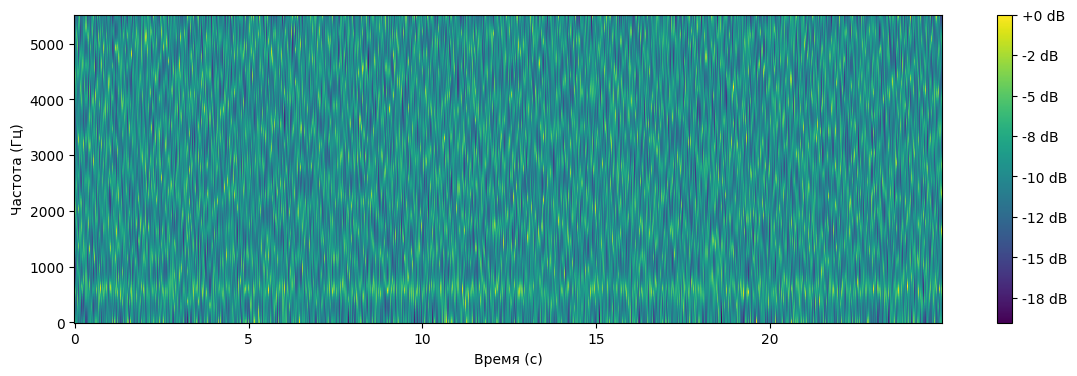

In [ ]:
# Параметры для LPC анализа
lpc_order = 20  # Порядок линейного предсказания
frame_length = 320  # Длина окна (кадра) для линейного предсказания
worN = 512

# Вычисляем LPC спектр
envelope = LPC_spectrum(data_11_wn_sin, lpc_order, frame_length, worN)

# Визуализация LPC спектра
plt.figure(figsize=(14, 4))
img = librosa.display.specshow(
    envelope,
    sr=sr_11_wn_sin,
    hop_length=frame_length,
    x_axis="time",
    y_axis="linear",
    cmap="viridis",
)
plt.colorbar(img, format="%+2.f dB")
plt.xlabel("Время (с)")
plt.ylabel("Частота (Гц)")
plt.show()

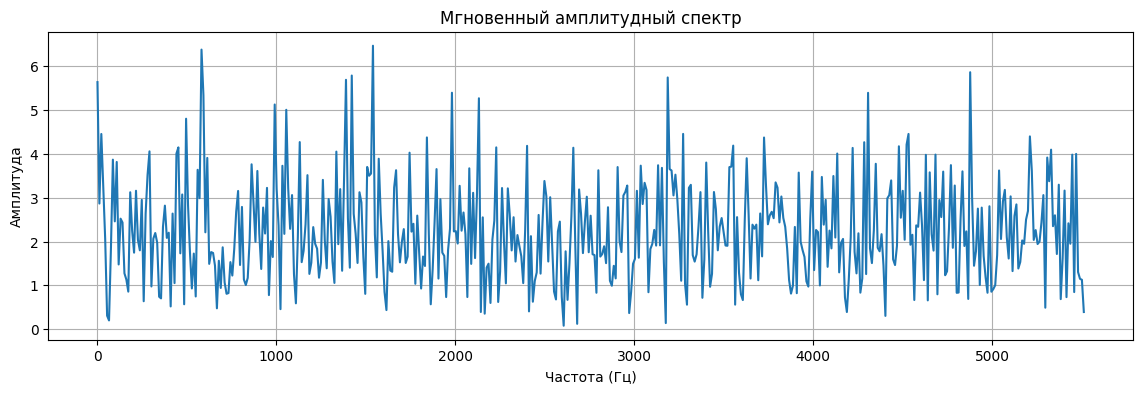

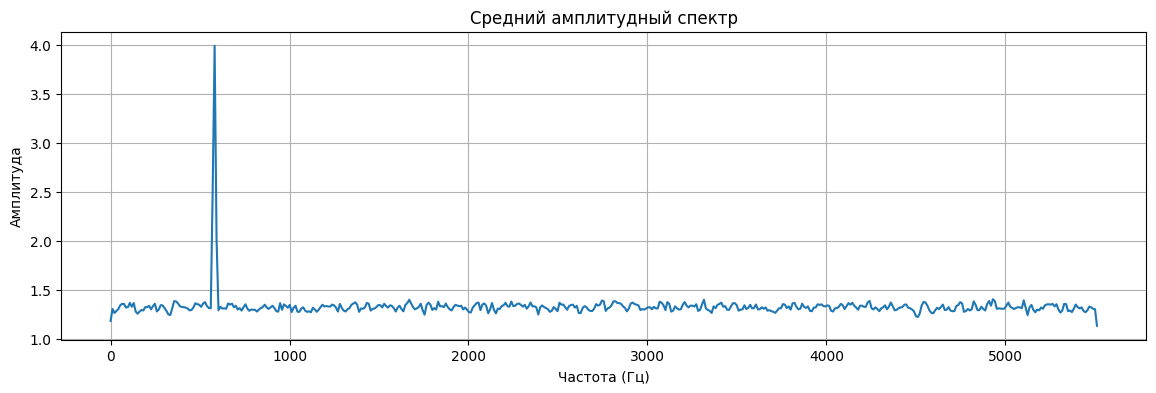

In [ ]:
# Строим мгновенный (на отдельном кадре) амплитудный спектр сигнала
fft_size = 1024
start_point = 1000
fft_inst = np.abs(np.fft.fft(data_11_wn_sin[start_point : start_point + fft_size]))
freqs = librosa.fft_frequencies(sr=sr_11_wn_sin, n_fft=fft_size)

# Визуализация мгновенного амплитудного спектра сигнала
plt.figure(figsize=(14, 4))
plt.plot(freqs, fft_inst[0 : 1 + fft_size // 2])
plt.title("Мгновенный амплитудный спектр")
plt.xlabel("Частота (Гц)")
plt.ylabel("Амплитуда")
plt.grid(True)

# Строим средний амплитудный спектр
S = np.abs(librosa.stft(data_11_wn_sin, n_fft=fft_size, hop_length=fft_size // 2))
fft_AVG = np.mean(S, axis=1)

# Визуализация
plt.figure(figsize=(14, 4))
plt.plot(freqs, fft_AVG[0 : 1 + fft_size // 2])
plt.title("Cредний амплитудный спектр")
plt.xlabel("Частота (Гц)")
plt.ylabel("Амплитуда")
plt.grid(True)
plt.show()

<div class="alert alert-block alert-success">
<b>Ответ на задание 1:</b>
<a id="answer-job1"></a>

* При каких параметрах КЛП-анализа правильно определяется частота гармоники сигнала?

Размер окна покрывает несколько периодов гарноники, применена оконная функция, порядок предсказания достаточно большой.

* Чем отличаются мгновенные спектры на отдельных кадрах?

Отличия в положение и высоте пиков, наличием других гармоник в окне.

* В чем состоит различие спектрограммы Фурье и спектрограммы КЛП?

Спектрограмма Фурье показывает полный спектр сигнала в каждом окне с огибающей и шумом, а спектрограмма КЛП только спектральную огибающую. Из-за этого КЛП не содержит информации о высоте тона.

</div>

<div class="alert alert-block alert-info">

## Задание 2.
<a id="job2"></a>

* Возьмите сигнал **40_sin1_sin2.wav**, содержащий две гармоники.

* Постройте КЛП спектрограммы сигнала с различным числом коэфициентов модели ($7, 15, 20$) и различными длинами окон ($64, 256, 1024$).
                                                                                                          
* Исследуйте мгновенные спектры (на отдельных кадрах).

### Вопросы

* При каких параметрах КЛП-анализа обнаруживаются 2 гармоники сигнала?

* С каким окном спектра Фурье можно различит гармоники?

* Чем отличаются мгновенные спектры, построенные на отдельных кадрах?

* В чем состоит различие широкополосной, узкополосной спектрограммы Фурье и спектрограммы КЛП?
</div>

In [ ]:
# Загружаем сигнал 40_sin1_sin2.wav
data_40_sin1_sin2, sr_40_sin1_sin2 = librosa.load(
    Speech_dir + "//40_sin1_sin2.wav", sr=None
)

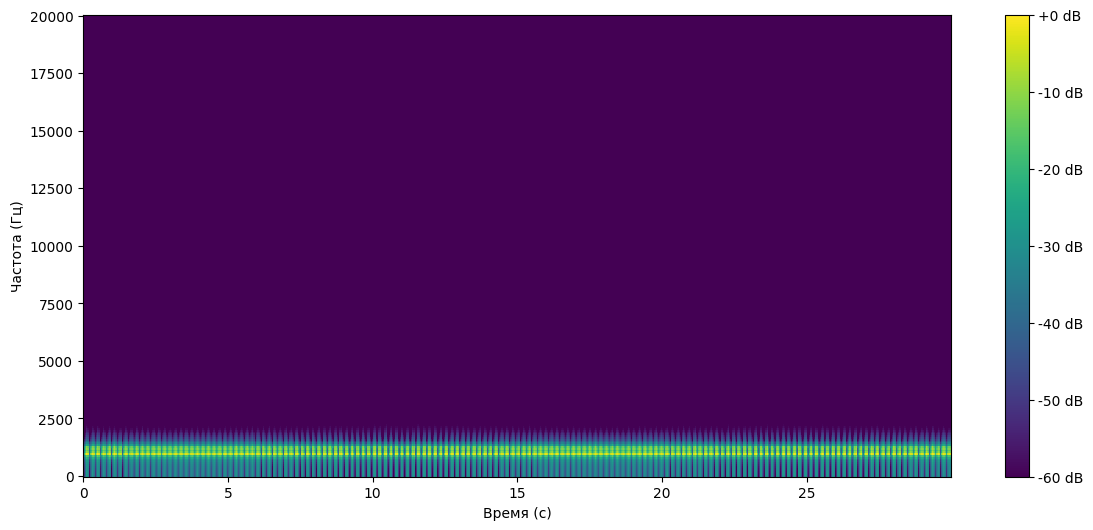

In [ ]:
# Параметры для LPC анализа
lpc_order = 20  # Порядок линейного предсказания
frame_length = 160  # Длина окна (кадра) для линейного предсказания
worN = 256

# Вычисляем LPC спектр
envelope = LPC_spectrum(data_40_sin1_sin2, lpc_order, frame_length, worN)

# Визуализация LPC спектра
plt.figure(figsize=(14, 6))
img = librosa.display.specshow(
    envelope,
    sr=sr_40_sin1_sin2,
    hop_length=frame_length,
    x_axis="time",
    y_axis="linear",
    cmap="viridis",
)
plt.colorbar(img, format="%+2.f dB")
plt.xlabel("Время (с)")
plt.ylabel("Частота (Гц)")
plt.show()

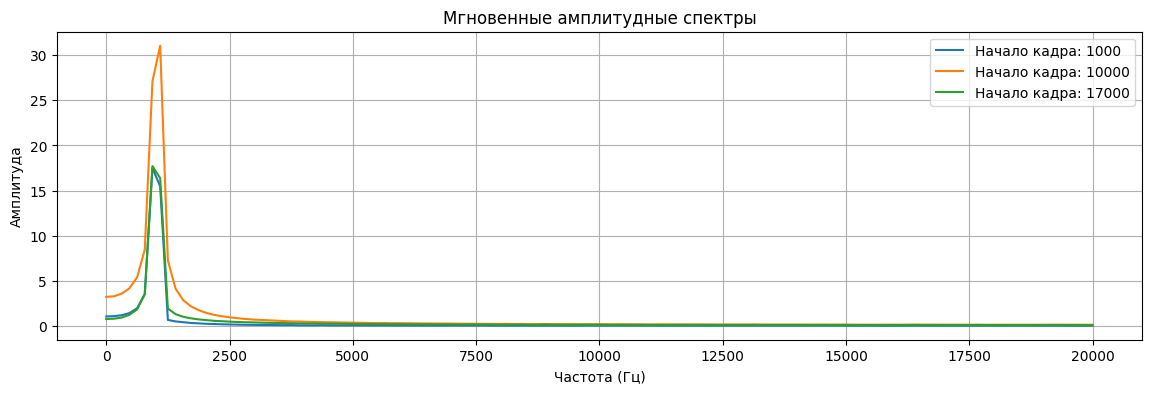

In [ ]:
# Строим мгновенные (на отдельноых кадрах) амплитудные спектры сигнала
fft_size = 256
freqs = librosa.fft_frequencies(sr=sr_40_sin1_sin2, n_fft=fft_size)

plt.figure(figsize=(14, 4))
plt.title("Мгновенные амплитудные спектры")
plt.xlabel("Частота (Гц)")
plt.ylabel("Амплитуда")

start_point = [1000, 10000, 17000]
for i in range(3):
    fft_inst = np.abs(
        np.fft.fft(data_40_sin1_sin2[start_point[i] : start_point[i] + fft_size])
    )
    plt.plot(
        freqs,
        fft_inst[0 : 1 + fft_size // 2],
        label="Начало кадра: {:d}".format(start_point[i]),
    )
plt.legend(loc=1)
plt.grid(True)

<div class="alert alert-block alert-success">
<b>Ответ на задание 2:</b>
<a id="answer-job2"></a>

* При каких параметрах КЛП-анализа обнаруживаются 2 гармоники сигнала?

Чтобы обнаружить 2 гармоники через КЛП, нужен порядок модели p >= 4 для описания двух резонансов, длина окна должна охватывать несколько периодов обеих гармоник.

* С каким окном спектра Фурье можно различит гармоники?

Прямоугольное даёт наибольшее частотное разрешение, однако в задачах с голосом чаще используют Хэмминга или Ханна.


* Чем отличаются мгновенные спектры, построенные на отдельных кадрах?

Отличия в высоте пиков, ширине лепестков, формой.

* В чем состоит различие широкополосной, узкополосной спектрограммы Фурье и спектрограммы КЛП?

Широкополосная - показывает временную динамику со сглаженными пиками и чёткими временными границами;
Узкополосная - показывает отдельные гармонические составляющие и их изменение по времени;
КЛП - показывает только спектральную огибающую без гармонической структуры.

</div>

<div class="alert alert-block alert-info">

## Задание 3.
<a id="job3"></a>

* Постройте для сигнала **11_100Hz.wav** спектрограммы сигнала с различными длинами окон ($64, 512, 2048$)

* При каких параметрах анализа проявляются импульсные и волновые свойства сигнала?
</div>

In [ ]:
# Загружаем сигнал 11_100Hz.wav
data_11_100Hz, sr_11_100Hz = librosa.load(Speech_dir + "//11_100HZ.WAV", sr=None)

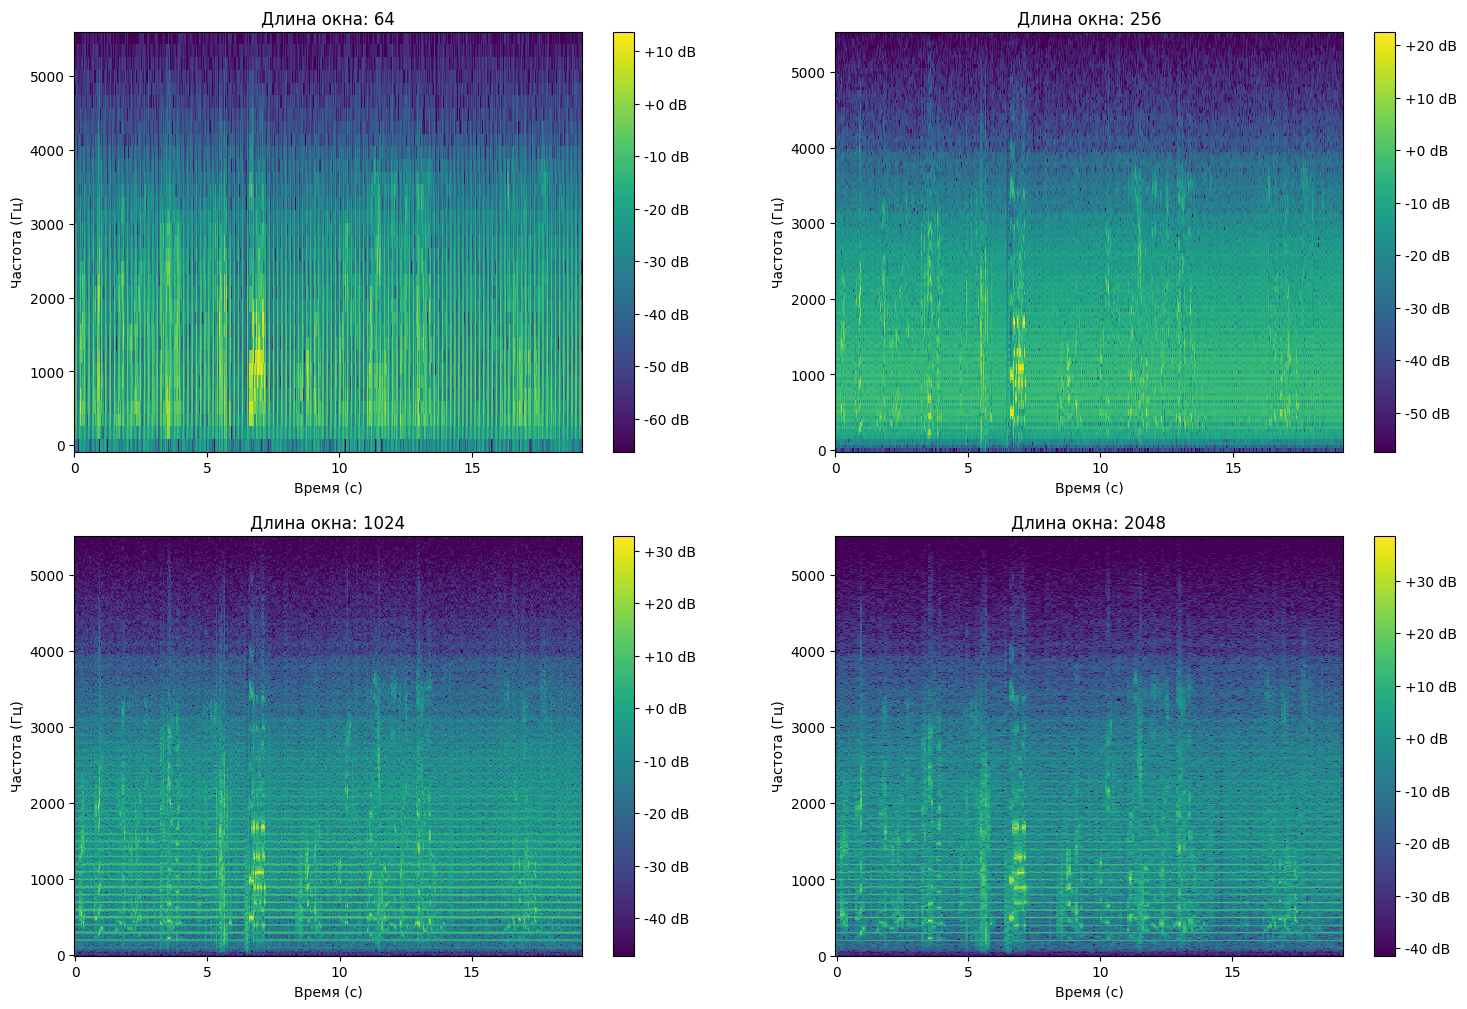

In [ ]:
# Строим спектрограммы сигнала 11_100Hz
fft_size = [64, 256, 1024, 2048]

plt.figure(figsize=(18, 12))

for i in range(4):
    plt.subplot(2, 2, i + 1)
    X = librosa.stft(data_11_100Hz, n_fft=fft_size[i], hop_length=fft_size[i] // 2)
    Xdb = librosa.amplitude_to_db(abs(X))

    img = librosa.display.specshow(
        Xdb,
        sr=sr_11_100Hz,
        x_axis="time",
        y_axis="linear",
        cmap="viridis",
        n_fft=fft_size[i],
        hop_length=fft_size[i] // 2,
    )
    plt.colorbar(img, format="%+2.f dB")
    plt.xlabel("Время (с)")
    plt.ylabel("Частота (Гц)")
    plt.title("Длина окна: {:d}".format(fft_size[i]))

<div class="alert alert-block alert-success">
<b>Ответ на задание 3:</b>
<a id="answer-job3"></a>

* При каких параметрах анализа проявляются импульсные и волновые свойства сигнала?

Импульсные видны при длине окна 64, при большем числе идёт сглаживание.

Волновые становятся видны при длине окна от 1024
</div>

<div class="alert alert-block alert-info">

## Задание 4.
<a id="job4"></a>
* Возьмите фонограмму речевого сигнала **11sp_fm1.wav**.

* Постройте КЛП спектрограммы сигнала с различным числом коэффициентов модели ($7, 15, 20$) и различными длинами окон ($64, 256, 1024$).

* Исследуйте мгновенные спектры (на отдельных кадрах).

### Вопросы

* Как выглядят формантные траектории?
* Как выглядят форманты на мгновенных спектрах?
</div>

In [ ]:
# Загружаем речевой сигнал 11sp_fm1.wav
data_11sp_fm1, sr_11sp_fm1 = librosa.load(Speech_dir + "//11sp_fm1.wav", sr=None)

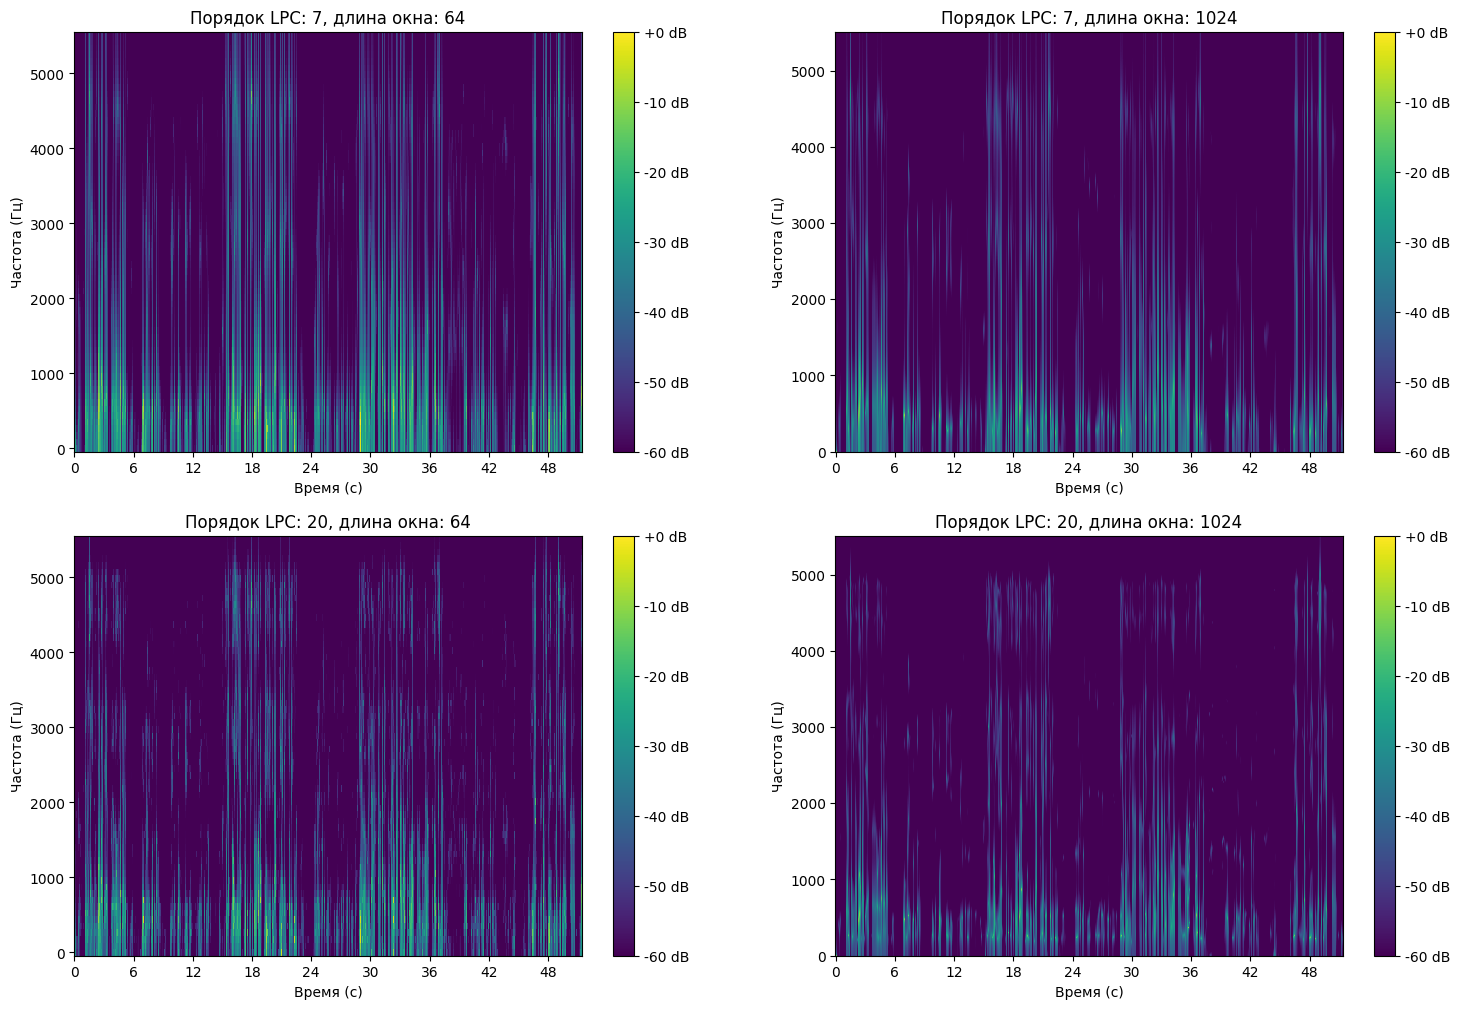

In [ ]:
# Строим КЛП спектрограммы речевого сигнала
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(18, 12))

fft_size = [64, 1024]
lpc_order = [7, 20]
frame_length = [42, 680]

for i in range(2):
    for j in range(2):
        envelope = LPC_spectrum(
            data_11sp_fm1, lpc_order[i], frame_length[j], fft_size[j]
        )

        img = librosa.display.specshow(
            envelope,
            sr=sr_11sp_fm1,
            hop_length=frame_length[j],
            x_axis="time",
            y_axis="linear",
            ax=axs[i, j],
            cmap="viridis",
        )
        img = librosa.display.specshow(
            envelope,
            sr=sr_11sp_fm1,
            hop_length=frame_length[j],
            x_axis="time",
            y_axis="linear",
            ax=axs[i, j],
            cmap="viridis",
        )

        fig.colorbar(img, ax=axs[i, j], format="%+2.0f dB")
        axs[i, j].set_title(
            "Порядок LPC: {:d}".format(lpc_order[i])
            + ", длина окна: {:d}".format(fft_size[j])
        )
        axs[i, j].set_xlabel("Время (с)")
        axs[i, j].set_ylabel("Частота (Гц)")

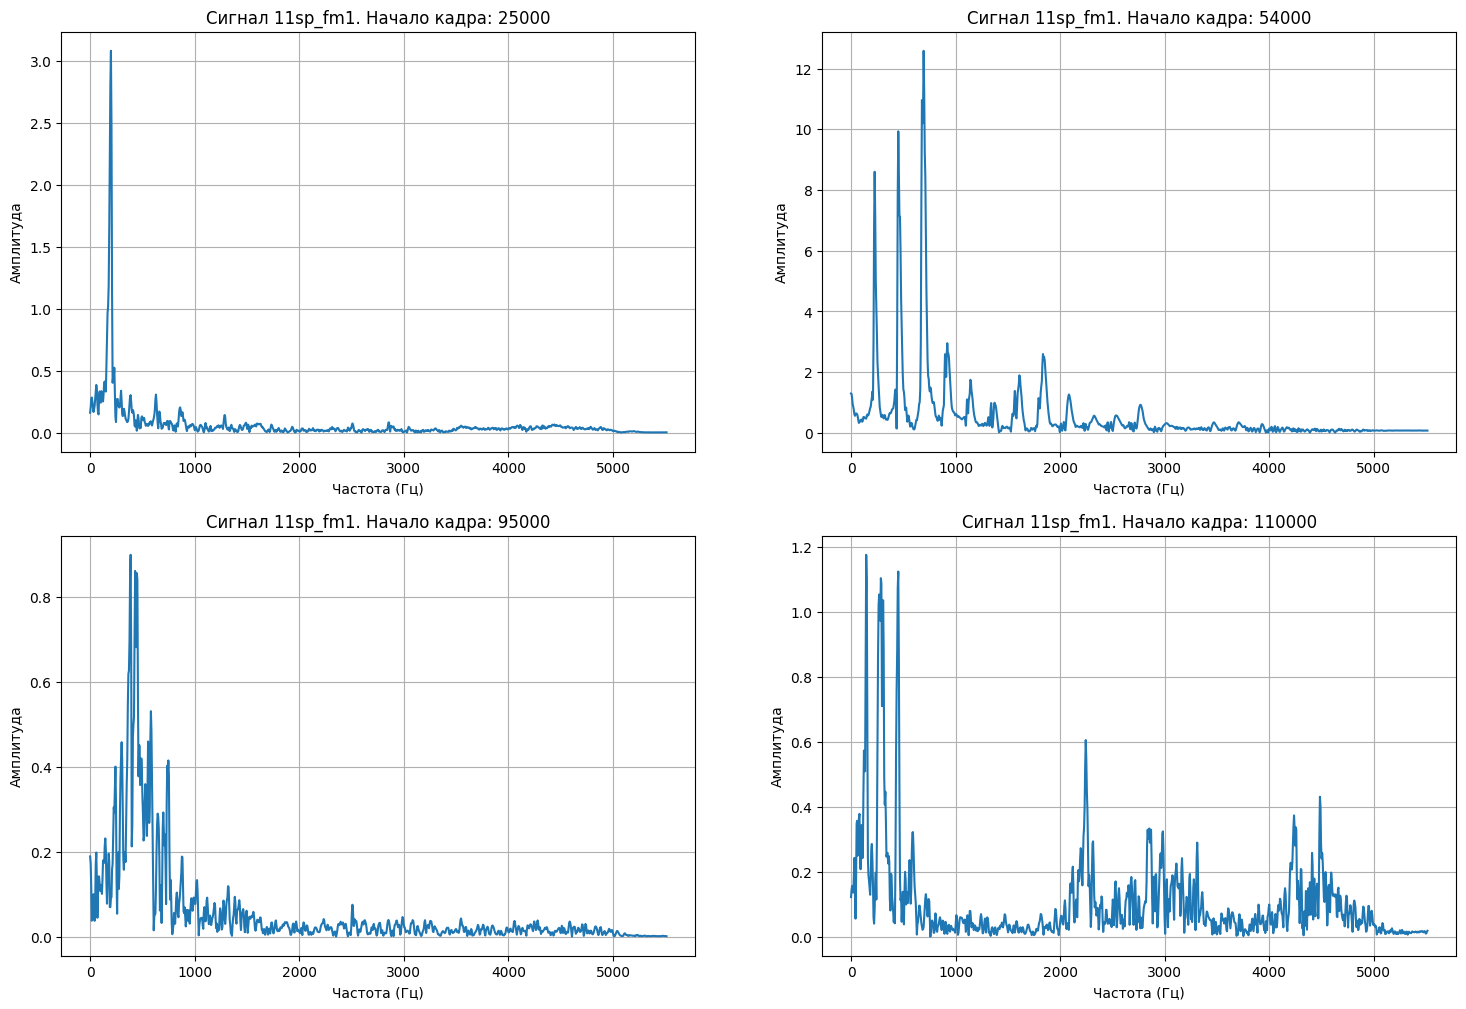

In [ ]:
# Строим мгновенные спектры речевого сигнала на разных участках
n_fft = 2048
freqs = librosa.fft_frequencies(sr=11025, n_fft=n_fft)

start = [25000, 54000, 95000, 110000]
plt.figure(figsize=(18, 12))

for i in range(4):
    plt.subplot(2, 2, i + 1)
    sp = np.abs(
        librosa.stft(
            data_11sp_fm1[start[i] : start[i] + n_fft],
            n_fft=n_fft,
            hop_length=n_fft + 1,
        )
    )
    plt.title("Сигнал 11sp_fm1. Начало кадра: {:d}".format(start[i]))

    plt.plot(freqs, sp)
    plt.xlabel("Частота (Гц)")
    plt.ylabel("Амплитуда")
    plt.grid(True)

<div class="alert alert-block alert-success">
<b>Ответ на задание 4:</b>
<a id="answer-job4"></a>

* Как выглядят формантные траектории?

Как высокие пики, которые при большом порядке разрываются, а при большом размере окна сглаживаются.

* Как выглядят форманты на мгновенных спектрах?

Как пики, ширина высота и количество которых зависит от числа порядков и прочих критериев, которые мы упомянали в прошлых пунктах.
</div>

<div class="alert alert-block alert-info">

## Задание 5.
<a id="job5"></a>
* Постройте для сигнала **11sp_fm1.wav** спектрограммы с различными длинами окон ($64, 256, 1024, 2048$).

* В каких случаях обнаруживаются форманты речевого сигнала?
</div>

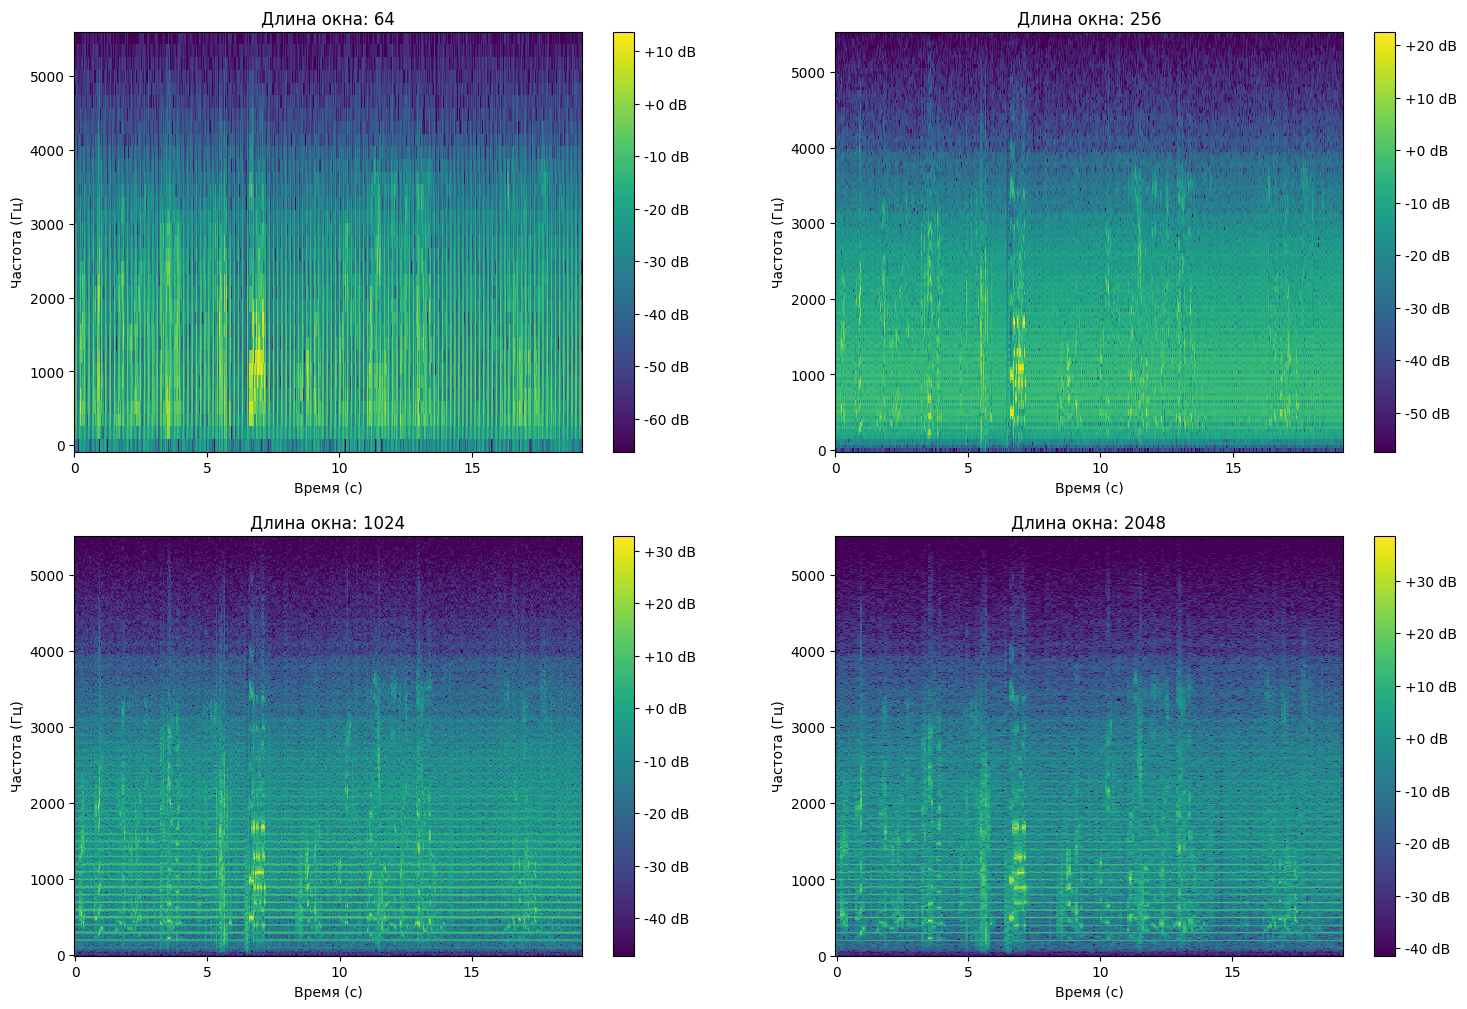

In [ ]:
# Строим спектрограммы речевого сигнала 11sp_fm1
fft_size = [64, 256, 1024, 2048]

plt.figure(figsize=(18, 12))

for i in range(4):
    plt.subplot(2, 2, i + 1)
    X = librosa.stft(data_11_100Hz, n_fft=fft_size[i], hop_length=fft_size[i] // 2)
    Xdb = librosa.amplitude_to_db(abs(X))

    img = librosa.display.specshow(
        Xdb,
        sr=sr_11_100Hz,
        hop_length=fft_size[i] // 2,
        x_axis="time",
        y_axis="linear",
        cmap="viridis",
    )
    plt.colorbar(img, format="%+2.f dB")
    plt.xlabel("Время (с)")
    plt.ylabel("Частота (Гц)")
    plt.title("Длина окна: {:d}".format(fft_size[i]))

<div class="alert alert-block alert-success">
<b>Ответ на задание 5:</b>
<a id="answer-job5"></a>

* В каких случаях обнаруживаются форманты речевого сигнала?

Длина окна достаточно большая (при 1024 становится более-менее видно по графикам)
</div>